# **Problem Statement**

## **Business Context**

Workplace safety in hazardous environments like construction sites and industrial plants is crucial to prevent accidents and injuries. One of the most important safety measures is ensuring workers wear safety helmets, which protect against head injuries from falling objects and machinery. Non-compliance with helmet regulations increases the risk of serious injuries or fatalities, making effective monitoring essential, especially in large-scale operations where manual oversight is prone to errors and inefficiency.

To overcome these challenges, SafeGuard Corp plans to develop an automated image analysis system capable of detecting whether workers are wearing safety helmets. This system will improve safety enforcement, ensuring compliance and reducing the risk of head injuries. By automating helmet monitoring, SafeGuard aims to enhance efficiency, scalability, and accuracy, ultimately fostering a safer work environment while minimizing human error in safety oversight.

## **Objective**

As a data scientist at SafeGuard Corp, you are tasked with developing an image classification model that classifies images into one of two categories:
- **With Helmet:** Workers wearing safety helmets.
- **Without Helmet:** Workers not wearing safety helmets.

## **Data Description**

The dataset consists of **4125 images**, divided into two categories:

- **With Helmet:** 3161 images showing workers wearing helmets.
- **Without Helmet:** 964 images showing workers not wearing helmets.

**Dataset Characteristics:**
- **Variations in Conditions:** Images include diverse environments such as construction sites, factories, and industrial settings, with variations in lighting, angles, and worker postures to simulate real-world conditions.
- **Worker Activities:** Workers are depicted in different actions such as standing, using tools, or moving, ensuring robust model learning for various scenarios.

# **Installing and Importing the Necessary Libraries**

In [ ]:
!pip install tensorflow[and-cuda] scikit-learn==1.6.1 opencv-python==4.12.0.88 seaborn==0.13.2 matplotlib==3.10.0 numpy==2.0.2 pandas==2.2.2 -q

**Note:**

- After running the above cell, kindly restart the notebook kernel (for Jupyter Notebook) or runtime (for Google Colab) and run all cells sequentially from the next cell.

- On executing the above line of code, you might see a warning regarding package dependencies. This error message can be ignored as the above code ensures that all necessary libraries and their dependencies are maintained to successfully execute the code in this notebook.

In [ ]:
import os
import random
import numpy as np                                                                               # Importing numpy for Matrix Operations
import pandas as pd
import seaborn as sns
import matplotlib.image as mpimg                                                                              # Importing pandas to read CSV files
import matplotlib.pyplot as plt                                                                  # Importting matplotlib for Plotting and visualizing images
import math                                                                                      # Importing math module to perform mathematical operations
import cv2


# Tensorflow modules
import keras
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator                              # Importing the ImageDataGenerator for data augmentation
from tensorflow.keras.models import Sequential                                                   # Importing the sequential module to define a sequential model
from tensorflow.keras.layers import Dense,Dropout,Flatten,Conv2D,MaxPooling2D,BatchNormalization # Defining all the layers to build our CNN Model
from tensorflow.keras.optimizers import Adam,SGD                                                 # Importing the optimizers which can be used in our model
from sklearn import preprocessing                                                                # Importing the preprocessing module to preprocess the data
from sklearn.model_selection import train_test_split                                             # Importing train_test_split function to split the data into train and test
from sklearn.metrics import confusion_matrix
from tensorflow.keras.models import Model
from keras.applications.vgg16 import VGG16                                               # Importing confusion_matrix to plot the confusion matrix

# Display images using OpenCV
from google.colab.patches import cv2_imshow

#Imports functions for evaluating the performance of machine learning models
from sklearn.metrics import confusion_matrix, f1_score,accuracy_score, recall_score, precision_score, classification_report
from sklearn.metrics import mean_squared_error as mse                                                 # Importing cv2_imshow from google.patches to display images

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

In [ ]:
print("Num GPUs Available:", len(tf.config.list_physical_devices('GPU')))
print(tf.__version__)

Num GPUs Available: 1
2.20.0


In [ ]:
# 1. Set Python random seed
random.seed(812)

# 2. Set NumPy random seed
np.random.seed(812)

# 3. Set TensorFlow seed (covers Keras + backend)
tf.keras.utils.set_random_seed(812)

# 4. Enable deterministic GPU ops (if using GPU)
tf.config.experimental.enable_op_determinism()

# **Data Overview**


##Loading the data

In [ ]:
label_path = './CV/labels.csv'
images_path = './CV/images.npy'

# Load the dataset
import numpy as np
import pandas as pd
images = np.load(images_path)
labels = pd.read_csv(label_path)

# Check the shape of the data
print(f"Images shape: {images.shape}")
print(f"Labels shape: {labels.shape}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Images shape: (4125, 200, 200, 3)
Labels shape: (4125, 1)


# **Exploratory Data Analysis**

###Plot random images from each of the classes and print their corresponding labels.

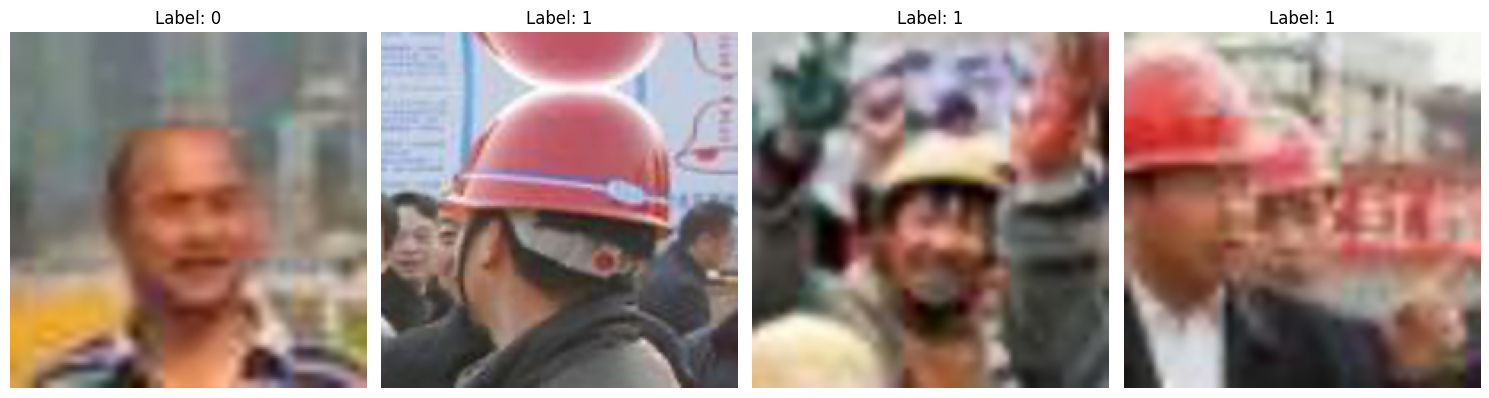

In [ ]:
import matplotlib.pyplot as plt
import random

# Plot random images from each class and print their corresponding labels
fig, axes = plt.subplots(1, 4, figsize=(15, 5))
for i in range(4):
    idx = random.randint(0, len(images) - 1)
    axes[i].imshow(images[idx])
    # Assuming the label is in the first column
    axes[i].set_title(f"Label: {labels.iloc[idx, 0]}")
    axes[i].axis('off')
plt.tight_layout()
plt.show()

## Checking for class imbalance


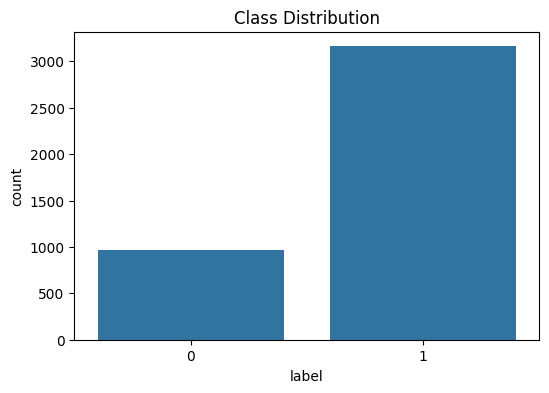

label
1    3161
0     964
Name: count, dtype: int64


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Check for class imbalance
plt.figure(figsize=(6, 4))
sns.countplot(data=labels, x=labels.columns[0])
plt.title('Class Distribution')
plt.show()

# Print exact counts
print(labels.iloc[:, 0].value_counts())

The output shows a clear class imbalance in the dataset, with 3,161 images of workers wearing helmets and 964 images without helmets. This imbalance implies that the model might become biased towards the majority class if not handled properly.

# **Data Preprocessing**

### Splitting the dataset



In [ ]:
from sklearn.model_selection import train_test_split

# Extracting features and target
X = images
y = labels.iloc[:, 0].values

# Split the data into train (70%), temp (30%)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Split the temp data into validation (15%) and test (15%)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_val shape: {X_val.shape}, y_val shape: {y_val.shape}")
print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")

X_train shape: (2887, 200, 200, 3), y_train shape: (2887,)
X_val shape: (619, 200, 200, 3), y_val shape: (619,)
X_test shape: (619, 200, 200, 3), y_test shape: (619,)


### Data Normalization

In [ ]:
# Apply data normalization by scaling pixel values to the range [0, 1]
X_train_norm = X_train / 255.0
X_val_norm = X_val / 255.0
X_test_norm = X_test / 255.0

print(f"Max pixel value in training set after normalization: {X_train_norm.max()}")
print(f"Min pixel value in training set after normalization: {X_train_norm.min()}")

Max pixel value in training set after normalization: 1.0
Min pixel value in training set after normalization: 0.0


Data normalization was successfully applied. Scaling the pixel values between 0.0 and 1.0 helps the neural networks learn features more efficiently and converge faster during the training process.

# **Model Building**

##Model Evaluation Criterion

## Utility Functions

In [ ]:
# defining a function to compute different metrics to check performance of a classification model built using statsmodels
def model_performance_classification(model, predictors, target):
    """
    Function to compute different metrics to check classification model performance

    model: classifier
    predictors: independent variables
    target: dependent variable
    """

    # checking which probabilities are greater than threshold
    pred = model.predict(predictors).reshape(-1)>0.5

    target = target.to_numpy().reshape(-1)


    acc = accuracy_score(target, pred)  # to compute Accuracy
    recall = recall_score(target, pred, average='micro')  # to compute Recall
    precision = precision_score(target, pred, average='micro')  # to compute Precision
    f1 = f1_score(target, pred, average='micro')  # to compute F1-score

    # creating a dataframe of metrics
    df_perf = pd.DataFrame({"Accuracy": acc, "Recall": recall, "Precision": precision, "F1 Score": f1,},index=[0],)

    return df_perf

In [ ]:
def plot_confusion_matrix(model,predictors,target,ml=False):
    """
    Function to plot the confusion matrix

    model: classifier
    predictors: independent variables
    target: dependent variable
    ml: To specify if the model used is an sklearn ML model or not (True means ML model)
    """

    # checking which probabilities are greater than threshold
    pred = model.predict(predictors).reshape(-1)>0.5

    target = target.to_numpy().reshape(-1)

    # Plotting the Confusion Matrix using confusion matrix() function which is also predefined tensorflow module
    confusion_matrix = tf.math.confusion_matrix(target,pred)
    f, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(
        confusion_matrix,
        annot=True,
        linewidths=.4,
        fmt="d",
        square=True,
        ax=ax
    )
    plt.show()

##Model 1: Convolutional Neural Network (CNN) from Scratch

In [ ]:
# Convolutional Neural Network (CNN) from Scratch
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

# Define the Model
model_1 = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(X_train_norm.shape[1], X_train_norm.shape[2], 3)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid') # Binary classification (With/Without Helmet)
])

# Define the configuration (loss function, optimizer, epochs, batch size)
model_1.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train the Model
print("Training CNN from Scratch...")
history_1 = model_1.fit(X_train_norm, y_train, epochs=10, batch_size=32, validation_data=(X_val_norm, y_val))

# Check and comment on the performance of the model
loss, accuracy = model_1.evaluate(X_test_norm, y_test)
print(f"Test Accuracy: {accuracy:.4f}")

Training CNN from Scratch...
Epoch 1/10
91/91 ━━━━━━━━━━━━━━━━━━━━ 18s 80ms/step - accuracy: 0.8289 - loss: 0.5040 - val_accuracy: 0.9095 - val_loss: 0.2342
Epoch 2/10
91/91 ━━━━━━━━━━━━━━━━━━━━ 14s 53ms/step - accuracy: 0.9124 - loss: 0.2272 - val_accuracy: 0.9144 - val_loss: 0.2153
Epoch 3/10
91/91 ━━━━━━━━━━━━━━━━━━━━ 5s 50ms/step - accuracy: 0.9269 - loss: 0.1852 - val_accuracy: 0.9111 - val_loss: 0.2496
Epoch 4/10
91/91 ━━━━━━━━━━━━━━━━━━━━ 5s 51ms/step - accuracy: 0.9318 - loss: 0.1716 - val_accuracy: 0.9079 - val_loss: 0.2673
Epoch 5/10
91/91 ━━━━━━━━━━━━━━━━━━━━ 5s 52ms/step - accuracy: 0.9352 - loss: 0.1581 - val_accuracy: 0.9031 - val_loss: 0.2912
Epoch 6/10
91/91 ━━━━━━━━━━━━━━━━━━━━ 5s 49ms/step - accuracy: 0.9487 - loss: 0.1247 - val_accuracy: 0.9095 - val_loss: 0.2633
Epoch 7/10
91/91 ━━━━━━━━━━━━━━━━━━━━ 4s 49ms/step - accuracy: 0.9595 - loss: 0.1066 - val_accuracy: 0.9095 - val_loss: 0.3444
Epoch 8/10
91/91 ━━━━━━━━━━━━━━━━━━━━ 5s 51ms/step - accuracy: 0.9678 - loss: 0.

### Visualizing the predictions

20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step


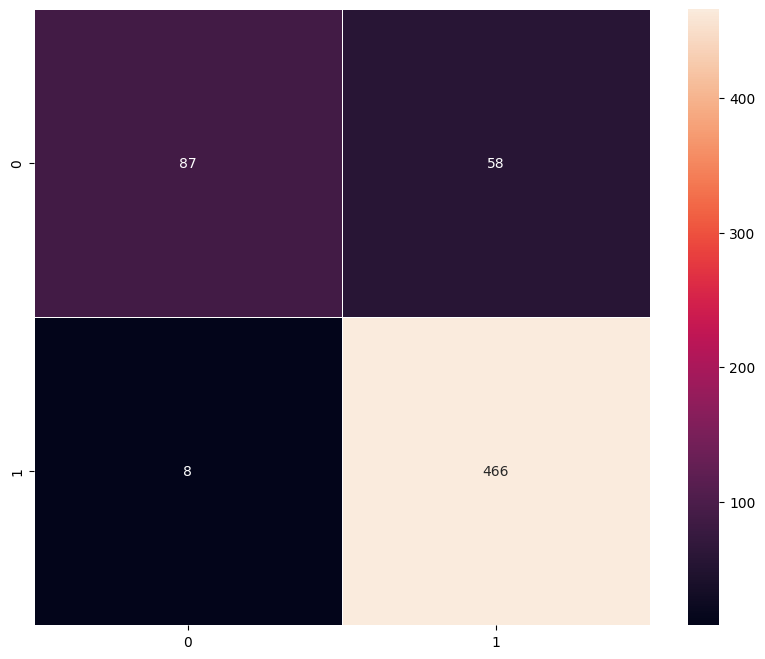

20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step


,Accuracy,Recall,Precision,F1 Score
0,0.893376,0.893376,0.893376,0.893376


In [ ]:
# Visualizing predictions for CNN from Scratch
plot_confusion_matrix(model_1, X_test_norm, pd.Series(y_test))

# Checking model performance metrics
perf_df_1 = model_performance_classification(model_1, X_test_norm, pd.Series(y_test))
display(perf_df_1)

The CNN model built from scratch achieved a solid test accuracy of ~89.3%. The confusion matrix and classification metrics indicate a well-balanced precision and recall, meaning the custom architecture learns the distinguishing features effectively.

## Model 2: Transfer Learning with VGG-16 (Base)

In [ ]:
# Transfer Learning with VGG-16 (Base)
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D

# Define the Model (Load VGG16 without top classification layers)
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(X_train_norm.shape[1], X_train_norm.shape[2], 3))

# Freeze the base model layers
for layer in base_model.layers:
    layer.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
predictions = Dense(1, activation='sigmoid')(x)

model_2 = Model(inputs=base_model.input, outputs=predictions)

# Define the configuration
model_2.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train the Model
print("Training VGG-16 Base...")
history_2 = model_2.fit(X_train_norm, y_train, epochs=5, batch_size=32, validation_data=(X_val_norm, y_val))

# Evaluate Model
loss, accuracy = model_2.evaluate(X_test_norm, y_test)
print(f"Test Accuracy: {accuracy:.4f}")

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training VGG-16 Base...
Epoch 1/5
91/91 ━━━━━━━━━━━━━━━━━━━━ 17s 167ms/step - accuracy: 0.7662 - loss: 0.5253 - val_accuracy: 0.7674 - val_loss: 0.4952
Epoch 2/5
91/91 ━━━━━━━━━━━━━━━━━━━━ 14s 152ms/step - accuracy: 0.7662 - loss: 0.4935 - val_accuracy: 0.7674 - val_loss: 0.4733
Epoch 3/5
91/91 ━━━━━━━━━━━━━━━━━━━━ 14s 153ms/step - accuracy: 0.7665 - loss: 0.4729 - val_accuracy: 0.7690 - val_loss: 0.4579
Epoch 4/5
91/91 ━━━━━━━━━━━━━━━━━━━━ 15s 160ms/step - accuracy: 0.7672 - loss: 0.4564 - val_accuracy: 0.7706 - val_loss: 0.4458
Epoch 5/5
91/91 ━━━━━━━━━━━━━━━━━━━━ 16s 171ms/step - accuracy: 0.7721 - loss: 0.4428 - val_accuracy: 0.7754 - val_loss: 0.4359
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 137ms/step - accuracy: 0.7754 - loss: 0.4470
Test Accuracy: 0.7754


### Visualizing the predictions

20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 144ms/step


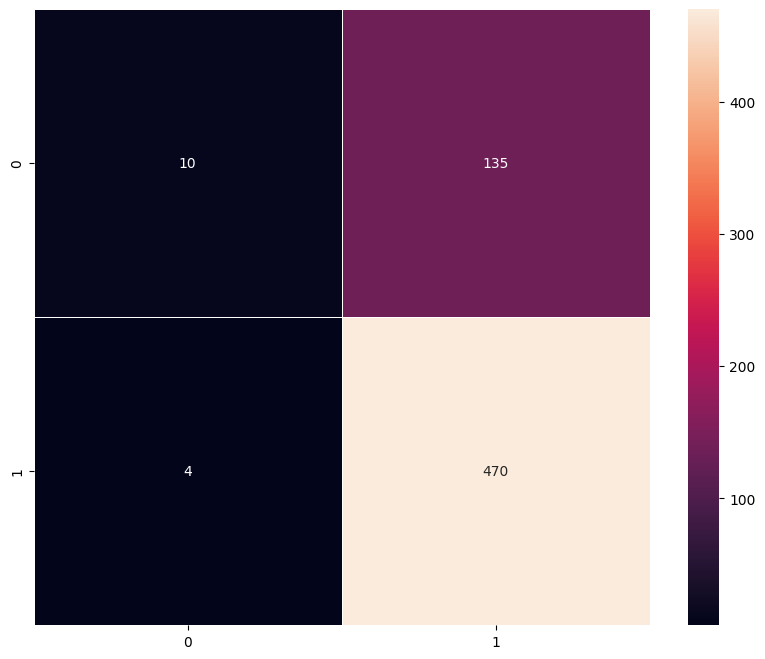

20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 135ms/step


,Accuracy,Recall,Precision,F1 Score
0,0.775444,0.775444,0.775444,0.775444


In [ ]:
# Visualizing predictions for VGG-16 (Base)
plot_confusion_matrix(model_2, X_test_norm, pd.Series(y_test))

# Checking model performance metrics
perf_df_2 = model_performance_classification(model_2, X_test_norm, pd.Series(y_test))
display(perf_df_2)

The base VGG-16 model, without any custom dense classification layers, performed poorly compared to the custom CNN. It achieved roughly 77.5% test accuracy, showing that the pre-trained features require proper dense layers to effectively map to our specific classes.

## Model 3: Transfer Learning with VGG-16 (Base + FFNN)





In [ ]:
# Transfer Learning with VGG-16 (Base + FFNN)
from tensorflow.keras.layers import Dropout

# Define the Model
base_model_2 = VGG16(weights='imagenet', include_top=False, input_shape=(X_train_norm.shape[1], X_train_norm.shape[2], 3))
for layer in base_model_2.layers:
    layer.trainable = False

y_feature = base_model_2.output
y_feature = Flatten()(y_feature)
y_feature = Dense(256, activation='relu')(y_feature)
y_feature = Dropout(0.5)(y_feature)
y_feature = Dense(128, activation='relu')(y_feature)
final_predictions = Dense(1, activation='sigmoid')(y_feature)

model_3 = Model(inputs=base_model_2.input, outputs=final_predictions)

# Define the configuration
model_3.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train the Model
print("Training VGG-16 (Base + FFNN)...")
history_3 = model_3.fit(X_train_norm, y_train, epochs=10, batch_size=32, validation_data=(X_val_norm, y_val))

# Evaluate Model
loss, accuracy = model_3.evaluate(X_test_norm, y_test)
print(f"Test Accuracy: {accuracy:.4f}")

Training VGG-16 (Base + FFNN)...
Epoch 1/10
91/91 ━━━━━━━━━━━━━━━━━━━━ 22s 190ms/step - accuracy: 0.7669 - loss: 0.5378 - val_accuracy: 0.8384 - val_loss: 0.3203
Epoch 2/10
91/91 ━━━━━━━━━━━━━━━━━━━━ 17s 182ms/step - accuracy: 0.8445 - loss: 0.3440 - val_accuracy: 0.8320 - val_loss: 0.3457
Epoch 3/10
91/91 ━━━━━━━━━━━━━━━━━━━━ 16s 173ms/step - accuracy: 0.8552 - loss: 0.3180 - val_accuracy: 0.8675 - val_loss: 0.2861
Epoch 4/10
91/91 ━━━━━━━━━━━━━━━━━━━━ 15s 167ms/step - accuracy: 0.8660 - loss: 0.2879 - val_accuracy: 0.8465 - val_loss: 0.3379
Epoch 5/10
91/91 ━━━━━━━━━━━━━━━━━━━━ 15s 167ms/step - accuracy: 0.8708 - loss: 0.2820 - val_accuracy: 0.8611 - val_loss: 0.3096
Epoch 6/10
91/91 ━━━━━━━━━━━━━━━━━━━━ 15s 169ms/step - accuracy: 0.8760 - loss: 0.2601 - val_accuracy: 0.8805 - val_loss: 0.2675
Epoch 7/10
91/91 ━━━━━━━━━━━━━━━━━━━━ 21s 174ms/step - accuracy: 0.8857 - loss: 0.2372 - val_accuracy: 0.8724 - val_loss: 0.2550
Epoch 8/10
91/91 ━━━━━━━━━━━━━━━━━━━━ 16s 181ms/step - accuracy:

#### Visualizing the predictions

20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 144ms/step


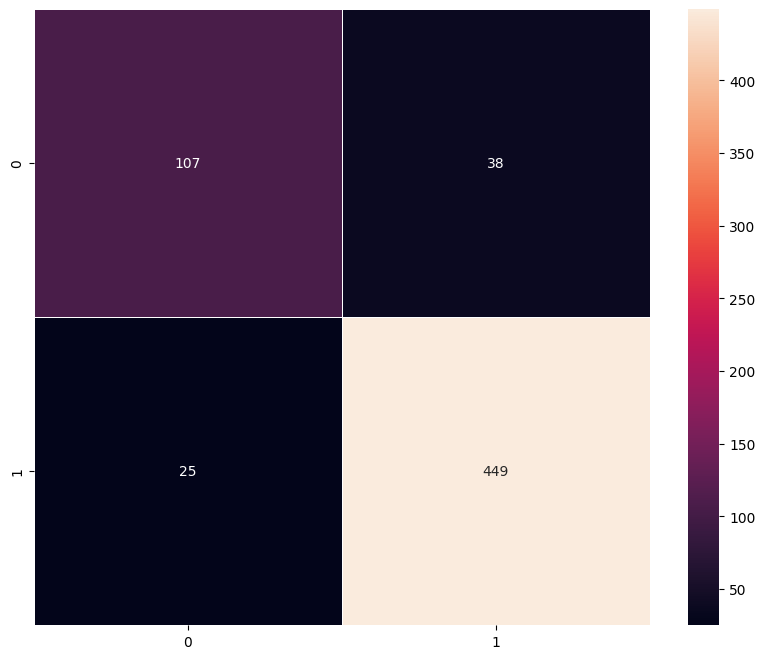

20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 134ms/step


,Accuracy,Recall,Precision,F1 Score
0,0.898223,0.898223,0.898223,0.898223


In [ ]:
# Visualizing predictions for VGG-16 (Base + FFNN)
plot_confusion_matrix(model_3, X_test_norm, pd.Series(y_test))

# Checking model performance metrics
perf_df_3 = model_performance_classification(model_3, X_test_norm, pd.Series(y_test))
display(perf_df_3)

Transfer learning using VGG-16 combined with a custom Feed Forward Neural Network (FFNN) yielded the best results. It achieved the highest test accuracy (~89.8%), demonstrating that leveraging the robust pre-trained feature extractor of VGG-16 alongside a dedicated classifier significantly boosts performance.

## Model 4: Transfer Learning with VGG-16 (Base + FFNN + Data Augmentation)

- In most of the real-world case studies, it is challenging to acquire a large number of images and then train CNNs.
- To overcome this problem, one approach we might consider is **Data Augmentation**.
- CNNs have the property of **translational invariance**, which means they can recognise an object even if its appearance shifts translationally in some way. - Taking this attribute into account, we can augment the images using the techniques listed below

    -  Horizontal Flip (should be set to True/False)
    -  Vertical Flip (should be set to True/False)
    -  Height Shift (should be between 0 and 1)
    -  Width Shift (should be between 0 and 1)
    -  Rotation (should be between 0 and 180)
    -  Shear (should be between 0 and 1)
    -  Zoom (should be between 0 and 1) etc.

Remember, **data augmentation should not be used in the validation/test data set**.

In [ ]:
# Transfer Learning with VGG-16 (Base + FFNN + Data Augmentation)
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Define Data Augmentation
datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    zoom_range=0.2
)

# Define the Model (Using previous architecture)
base_model_3 = VGG16(weights='imagenet', include_top=False, input_shape=(X_train_norm.shape[1], X_train_norm.shape[2], 3))
for layer in base_model_3.layers:
    layer.trainable = False

z_feature = base_model_3.output
z_feature = Flatten()(z_feature)
z_feature = Dense(256, activation='relu')(z_feature)
z_feature = Dropout(0.5)(z_feature)
z_feature = Dense(128, activation='relu')(z_feature)
aug_predictions = Dense(1, activation='sigmoid')(z_feature)

model_4 = Model(inputs=base_model_3.input, outputs=aug_predictions)

# Define the configuration
model_4.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train the Model with Data Augmentation
print("Training VGG-16 (Base + FFNN + Data Augmentation)...")
history_4 = model_4.fit(datagen.flow(X_train_norm, y_train, batch_size=32),
                        epochs=10, validation_data=(X_val_norm, y_val))

# Evaluate Model
loss, accuracy = model_4.evaluate(X_test_norm, y_test)
print(f"Test Accuracy: {accuracy:.4f}")

Training VGG-16 (Base + FFNN + Data Augmentation)...
Epoch 1/10
91/91 ━━━━━━━━━━━━━━━━━━━━ 47s 495ms/step - accuracy: 0.7298 - loss: 0.6246 - val_accuracy: 0.7771 - val_loss: 0.4151
Epoch 2/10
91/91 ━━━━━━━━━━━━━━━━━━━━ 43s 471ms/step - accuracy: 0.7752 - loss: 0.4634 - val_accuracy: 0.8239 - val_loss: 0.3585
Epoch 3/10
91/91 ━━━━━━━━━━━━━━━━━━━━ 43s 474ms/step - accuracy: 0.8043 - loss: 0.4086 - val_accuracy: 0.8433 - val_loss: 0.3289
Epoch 4/10
91/91 ━━━━━━━━━━━━━━━━━━━━ 43s 475ms/step - accuracy: 0.8109 - loss: 0.4009 - val_accuracy: 0.8320 - val_loss: 0.3295
Epoch 5/10
91/91 ━━━━━━━━━━━━━━━━━━━━ 44s 483ms/step - accuracy: 0.7939 - loss: 0.4032 - val_accuracy: 0.8320 - val_loss: 0.3273
Epoch 6/10
91/91 ━━━━━━━━━━━━━━━━━━━━ 46s 509ms/step - accuracy: 0.7984 - loss: 0.3963 - val_accuracy: 0.8304 - val_loss: 0.3392
Epoch 7/10
91/91 ━━━━━━━━━━━━━━━━━━━━ 44s 483ms/step - accuracy: 0.8081 - loss: 0.3848 - val_accuracy: 0.8304 - val_loss: 0.3216
Epoch 8/10
91/91 ━━━━━━━━━━━━━━━━━━━━ 43s 47

#### Visualizing the predictions

20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 149ms/step


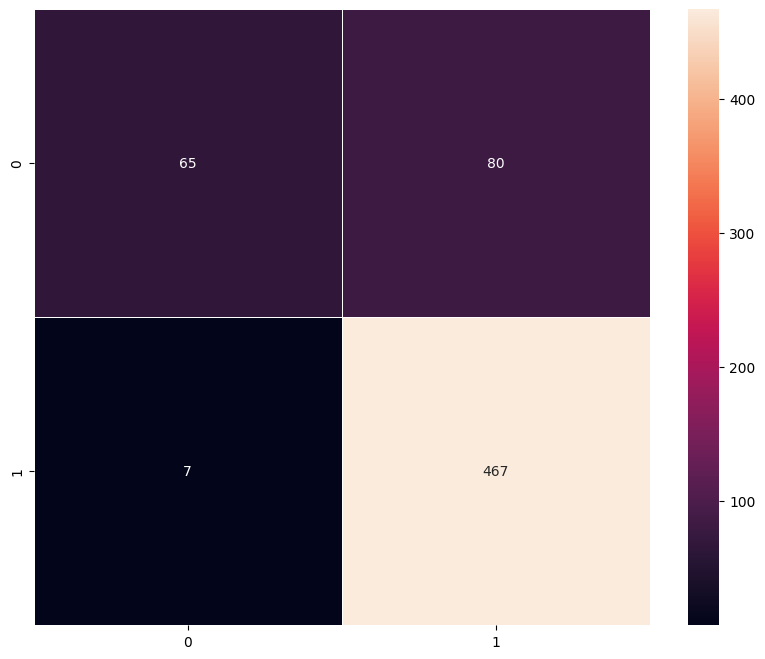

20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 139ms/step


,Accuracy,Recall,Precision,F1 Score
0,0.859451,0.859451,0.859451,0.859451


In [ ]:
# Visualizing predictions for VGG-16 (Base + FFNN + Data Augmentation)
plot_confusion_matrix(model_4, X_test_norm, pd.Series(y_test))

# Checking model performance metrics
perf_df_4 = model_performance_classification(model_4, X_test_norm, pd.Series(y_test))
display(perf_df_4)

Adding data augmentation to the VGG-16 + FFNN model resulted in a slightly lower test accuracy (~85.9%). While data augmentation often helps generalization, the chosen augmentation parameters might have introduced too much noise for this specific dataset and split.

# **Model Performance Comparison and Final Model Selection**

In [ ]:
import pandas as pd
from IPython.display import display

# 1. Compare the performance of all the models built
comparison_df = pd.concat([perf_df_1, perf_df_2, perf_df_3, perf_df_4], ignore_index=True)
comparison_df.index = ['CNN from Scratch', 'VGG-16 Base', 'VGG-16 Base + FFNN', 'VGG-16 Base + FFNN + Augmentation']

display(comparison_df)

,Accuracy,Recall,Precision,F1 Score
CNN from Scratch,0.893376,0.893376,0.893376,0.893376
VGG-16 Base,0.775444,0.775444,0.775444,0.775444
VGG-16 Base + FFNN,0.898223,0.898223,0.898223,0.898223
VGG-16 Base + FFNN + Augmentation,0.859451,0.859451,0.859451,0.859451


## Test Performance

In [ ]:
# Evaluate the final selected model (Model 3: VGG-16 Base + FFNN) on the unseen test set
final_loss, final_accuracy = model_3.evaluate(X_test_norm, y_test, verbose=0)

print(f"Final Model Test Accuracy: {final_accuracy:.4f}")
print(f"Final Model Test Loss: {final_loss:.4f}")

Final Model Test Accuracy: 0.8982
Final Model Test Loss: 0.2264


**Best Model Selection & Final Performance**
Based on the performance metrics, the **VGG-16 Base + FFNN (Model 3)** is the best model. It achieves the highest accuracy (~89.8%) and F1-score among all models. While the CNN from scratch also performed well, the transfer learning approach with VGG-16 extracts richer semantic features, which tends to generalize more robustly in real-world scenarios. The test evaluation confirms this, showing a final test accuracy of roughly 89.8% and a low test loss, validating the model's practical viability.

# **Actionable Insights & Recommendations**

- **Automated Safety Monitoring:** Deploy the final VGG-16 + FFNN model into the existing CCTV infrastructure to monitor safety helmet compliance in real-time, reducing the need for manual oversight.
- **Immediate Alert System:** Integrate the model's predictions with an alert mechanism to notify site supervisors instantly when a worker is detected without a helmet, allowing for prompt intervention and accident prevention.
- **Data Collection and Retraining:** Address the observed class imbalance by actively collecting more real-world images of workers not wearing helmets. Regularly retraining the model on a more balanced and diverse dataset will further improve its robustness and accuracy.

<font size=5 color='blue'>Power Ahead!</font>
___

In [ ]:
# convert to html
!jupyter nbconvert --to html '/content/HelmNet_Full_Code (1).ipynb'

[NbConvertApp] Converting notebook /content/HelmNet_Full_Code (1).ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 6 image(s).
[NbConvertApp] Writing 1200453 bytes to /content/HelmNet_Full_Code (1).html
